# CFPB - Customer Complaint Analysis

The **Consumer Financial Protection Bureau** (CFPB) is a U.S. government regulatory agency established to protect consumers in the financial marketplace. The agency operates a centralized system where consumers can submit complaints regarding financial institutions, prompting the company to review and respond. 
According to the official 2025 statistics: *the CFPB received around $6.63M$ consumer complaints via its registered portal, toll-free number, postal mail, referrals from other regulatory bodies, etc., and routed around $5.98M$ complaints to over $4K$ companies for review with an expected response TAT of ${<}15days$.*\
These archived reports contain detailed EDA breakdown: [[annual-report_2025](https://www.consumerfinance.gov/data-research/research-reports/2025-consumer-response-annual-report/)].[[annual-report_2024](https://www.consumerfinance.gov/data-research/research-reports/2024-consumer-response-annual-report/)].[[annual-report_2023](https://www.consumerfinance.gov/data-research/research-reports/consumer-response-annual-report-2023/)].[[annual-report_2022](https://www.consumerfinance.gov/data-research/research-reports/2022-consumer-response-annual-report/)].[[annual-report_2021](https://www.consumerfinance.gov/data-research/research-reports/2021-consumer-response-annual-report/)]\
The portal states: <span style="font-family:'Courier New', monospace; font-style:italic;">"Complaint narratives are consumers’ descriptions of their experiences in their own words"</span>; the CFPB only performs PII masking before uploading the narratives to the database. Consider the CFPB's description of the data collection process: <span style="font-family:'Courier New', monospace; font-style:italic;">"The Consumer Complaint Database shows the consumer's original products, sub-products, issues, and sub-issues selections consistent with the options available on the form at the time the consumer submitted the complaint"</span>. i.e., the data annotation is performed by the individual customers themselves, not something directly actionable by CFPB staff.
<div style="border: 2px solid black; padding: 15px; font-size: 1.2em; font-weight: bold; border-radius: 5px; width: max-content;">
    It is more sensible to spend effort understanding the themes and patterns within tagged complaints than trying to automatically assign those tags.
</div>



# Table of Contents

- [Extracting only the relevant data](#extracting-only-the-relevant-data)
- [Let's count](#lets-count)
- [Read between the lines](#read-between-the-lines)


## Extracting only the relevant data
As of 21-June-2026, the CFPB [Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/search/?dateRange=All&date_received_max=2026-06-20&date_received_min=2011-12-01&page=1&searchField=all&size=25&sort=created_date_desc&tab=List) hosted around $16M$ records dating back to 2011. Instead of downloading the entire database dump, we pulled a 3-month window of data via the CFPB API after accounting for the portal's 15-day publishing lag. Only records with written narratives were retrieved, thereby excluding at the server level the $98.1\%$ of records within that timeframe that contained only category tags and blank text.\
Although the database is a collection of self-reported experiences rather than a statistical sample of marketplace consumers, companies still use this complaint data to identify potential weaknesses in specific products or services and to make future improvements. 

In [1]:
Source_file = './data.csv'

%load_ext autoreload 
%autoreload 2
import numpy as np, pandas as pd
import warnings ; warnings.simplefilter("ignore")

Head = pd.read_csv(Source_file,
    header=0, index_col=False, dtype='string',
    nrows=5
).set_axis(range(1, 6),axis=0)
Head

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2026-03-04T15:21:40.000Z,Debt collection,Credit card debt,Communication tactics,Frequent or repeated calls,I am submitting this complaint regarding Midla...,<NA>,ENCORE CAPITAL GROUP INC.,FL,33417,<NA>,Web,2026-04-09T17:24:57.000Z,Closed with explanation,Yes,19966418
2,2026-03-04T18:21:34.000Z,Debt collection,Medical debt,Attempts to collect debt not owed,Debt is not yours,Revco debt collectors called and had my correc...,<NA>,"Revco Management, LLC",NY,14226,<NA>,Web,2026-03-04T18:30:13.000Z,Closed with non-monetary relief,Yes,19972144
3,2026-03-04T21:57:47.000Z,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,CDR Genesis is reporting a collection account ...,<NA>,"Rowland Avenue Management, Inc. A/KA Columbia ...",TX,754XX,<NA>,Web,2026-04-10T04:43:28.000Z,Closed with explanation,Yes,19981404
4,2026-03-04T21:04:23.000Z,Checking or savings account,Savings account,Managing an account,Deposits and withdrawals,XXXX XXXX {$3800.00} taken out my savings and ...,Company believes it acted appropriately as aut...,NAVY FEDERAL CREDIT UNION,VA,23320,<NA>,Web,2026-04-10T15:50:00.000Z,Closed with explanation,Yes,19978982
5,2026-03-07T05:24:36.000Z,Checking or savings account,Checking account,Managing an account,Cashing a check,I ordered a checkbook for my checking account ...,<NA>,"HOPE BANCORP, INC.",CA,90015,<NA>,Web,2026-03-07T08:21:00.000Z,Closed with monetary relief,Yes,20063160


In [2]:
from my_scripts import preprocessing

Data_Narrative,MASK_Names = preprocessing.clean_text(Source_file)
print(f'''#n_rows: {Data_Narrative.shape[0]}\nmin_date: {Data_Narrative["DateReceived"].min()}\nmax_date: {Data_Narrative["DateReceived"].max()} ''')
Data_Narrative.info()

HasNA('Product','Narrative'):0
#n_rows: 37620
min_date: 2026-03-04
max_date: 2026-06-01 
<class 'pandas.DataFrame'>
RangeIndex: 37620 entries, 0 to 37619
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   DateReceived  37620 non-null  period[D]
 1   Product       37620 non-null  category 
 2   SubProduct    37620 non-null  category 
 3   Narrative     37620 non-null  string   
 4   Company       37620 non-null  category 
dtypes: category(3), period[D](1), string(1)
memory usage: 48.8 MB


<Axes: title={'center': 'Distribution of Complaints by Product'}>

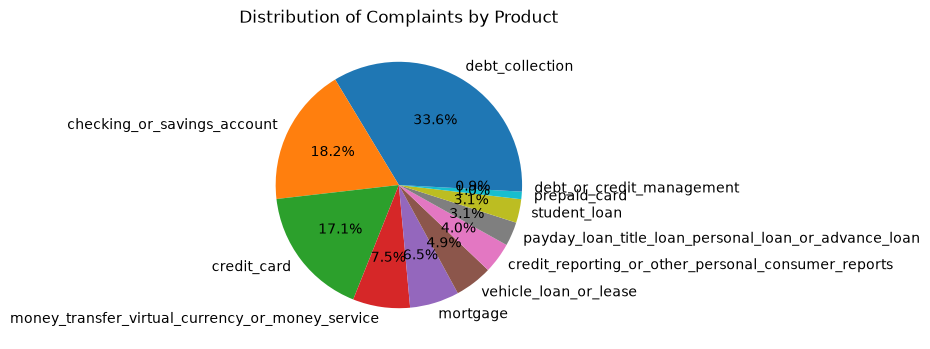

In [3]:
Summary = pd.pivot_table(Data_Narrative, 
    index="Product", 
    aggfunc={
        "SubProduct":'nunique',
        "Narrative":'count'
    },
    sort=False
).sort_values("Narrative",ascending=False)
Summary["Narrative"].plot(
    kind="pie",
    autopct="%.1f%%",
    ylabel="",
    title="Distribution of Complaints by Product",
    figsize=(4,4),
)

## Let's count 
Let us start with a simple idea: identify characteristic keywords—words that occur frequently within a particular complaint class but are relatively uncommon across other complaint classes. This can be achieved using [`class-based TF-IDF`](https://www.maartengrootendorst.com/blog/ctfidf/).

In [4]:
from my_scripts import ClassKeywordExtractor

cTfIdf = ClassKeywordExtractor.TopK_cTFIDF(ngram_range=(1,1),stop_words=MASK_Names,exclude_pos=ClassKeywordExtractor.POS_ALL-{'NOUN','PROPN','NUM'})
Top_Keywords_1 = cTfIdf.fit_transform(Data_Narrative["Narrative"],Data_Narrative["Product"])
Top_Keywords_1

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10,Top_11,Top_12,Top_13,Top_14,Top_15,Top_16,Top_17,Top_18,Top_19,Top_20
debt_collection,1006.34,1618d,jefferson,lvnv,credence,resurgent,caine,weiner,iq,ic,sunrise,waypoint,transworld,mcm,coll,jeffcapsys,pra,syst,columbia,oaks
credit_card,barclays,bilt,carecredit,comenity,barclay,elan,macys,aadvantage,1026.13,mattress,fare,sapphire,fnbo,robinhood,cashback,cardmember,synchronys,itinerary,expresss,avant
checking_or_savings_account,schwab,marcus,chexsystems,keybank,axos,webster,xxxxauto,provisional,contribution,passcode,stanley,albert,golden,yield,levy,hsa,etrade,bitcoin,federals,indemnity
credit_reporting_or_other_personal_consumer_reports,559.72,ltd.,fccpa,reaged,6801,tiefficiency,openedxxxx,1692d,dissemination,opened,u.c.c.,challenged,assailant,605,501.976,501.203,501.204,616617,accurately,xxxxcharge
student_loan,mohela,nelnet,pslf,aidvantage,idr,sallie,cri,navient,mae,edfinancial,driven,aes,fsa,climb,pheaa,ibr,doe,firstmark,tpd,studentaid.gov
prepaid_card,netspend,vanilla,way2go,blackhawk,conduent,incomm,edd,reliacard,skylight,apps,networks,comdata,true,irp,netspends,brinks,highvelocity,comdataxxxx,myprepaidcenter.com,bloomingdales
money_transfer_virtual_currency_or_money_service,coinbase,venmo,kraken,zelle,wise,robinhood,crypto,apps,bitcoin,skrill,moneygram,receiving,token,crypto.com,gemini,mercari,bitstamp,blockchain,revolut,correspondent
mortgage,shellpoint,respa,fha,newrez,sps,phh,appraisal,pennymac,carrington,selene,onity,loancare,pmi,00.00,cmg,1024.35,1024.41,amerihome,planet,qwr
debt_or_credit_management,americor,wentworth,subparagraph,jg,beyond,grt,telemarketing,facsimile,amazon,clearone,j.g.,cordoba,saint,503(b,pra,croa,advisors,organizations,neln,"1681c-2,1681"
payday_loan_title_loan_personal_loan_or_advance_loan,goodleap,solar,installer,mosaic,uprova,opploans,titlemax,loanmart,patientfi,affirms,sfc,lendingpoint,main,mw,corporatio,tower,hfd,greensky,scratchpay,klover


In [5]:
cTfIdf2 = ClassKeywordExtractor.TopK_cTFIDF(ngram_range=(2,4),stop_words=MASK_Names)
Top_Keywords_2to4 = cTfIdf2.fit_transform(Data_Narrative["Narrative"],Data_Narrative["Product"])
Top_Keywords_2to4

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10,Top_11,Top_12,Top_13,Top_14,Top_15,Top_16,Top_17,Top_18,Top_19,Top_20
debt_collection,report credit account,license collect,name original creditor,debt claim owe,provide follow information,include original sign agreement,license collect debt,contract other,right fdcpa,debt delete,creditor copy,original creditor copy,owe dispute,validation include original,full validation include,request full validation include,validation include original sign,agency pursuant,reporting agency pursuant,copy agreement contract
credit_card,defer interest,promotional balance,deferred interest,home depot,comenity bank,promotional financing,credit card issue,citi card,citi credit card,retroactive interest,call citi,capital one credit card,defer interest charge,citibank credit,chase credit card,apply card,contact citi,new credit card,citibank credit card,request synchrony
checking_or_savings_account,ally bank,atm withdrawal,provide provisional,mobile deposit,provide provisional credit,business check account,open checking,promotional bonus,monthly service,minimum balance,fargo deny claim,wells fargo deny claim,monthly service fee,atm deposit,open checking account,provisional credit issue,overdraft protection,credit reverse,regulation cc,e trade
credit_reporting_or_other_personal_consumer_reports,banking system violation,impair efficiency,reporting act 15 u.s.,efficiency banking system,impair efficiency banking,impair efficiency banking system,efficiency banking,act 15 u.s. code,date open balance,undermine public,reporting method,report impair efficiency,report impair,credit reporting inaccurate credit,continue functioning banking system,system unfair credit,banking system unfair,public confidence,accurate credit reporting inaccurate,reporting method undermine
student_loan,department education,qualifying payment,loan forgiveness,payment count,sallie mae,borrower defense,public service,student aid,administrative forbearance,federal student aid,income drive,drive repayment,income drive repayment,buyback request,private student,private student loan,public service loan,service loan forgiveness,public service loan forgiveness,drive repayment plan
prepaid_card,money network,direct express,activate card,back card,reward card,prepaid debit,cash apps,prepaid debit card,correct booking,netspend account,card lock,blackhawk network,say card,visa gift,vanilla visa,way2go card,decline fee,try activate,prepaid account,number back card
money_transfer_virtual_currency_or_money_service,western union,recipient account,cash app provide,request cash app,wallet address,complaint cash,complaint cash app,link bank account,cash apps,180 day hold,app block,issue paypal,cash app block,account cash app,contact cash app support,paypal multiple,paypal provide,paypal multiple time,account deactivate,cashapp account
mortgage,rocket mortgage,freedom mortgage,mortgage servicer,escrow analysis,trial payment,mortgage assistance,short sale,monthly mortgage,regulation x,escrow shortage,force place,place insurance,foreclosure activity,foreclosure sale,monthly mortgage payment,shellpoint mortgage,mitigation application,loss mitigation application,regard mortgage,flood insurance
debt_or_credit_management,enrol debt,violate right consumer,settlement program,item block remove,15 usc 605b.,fcra 15 usc 605b.,jg wentworth,usc 605b.,debt settlement program,item block,beyond finance,fcra 15 usc,settlement fee,need item block,need item block remove,need item,consumer fcra 15,violate right consumer fcra,consumer fcra 15 usc,right consumer fcra 15
payday_loan_title_loan_personal_loan_or_advance_loan,solar system,solar servicing,solar loan,onemain financial,dispute affirm,solar servicing llc,use affirm,contact affirm,world finance,payday loan,affirm deny,solar installation,regard solar,solar mosaic,main financial,one main financial,contact goodleap,affirm continue,system instal,complaint affirm


Here, we list the top 20 characteristic keywords for each complaint class, separately for unigrams and for 2,3,4-grams. The key observations are as follows:
- As a purely frequency-based approach, c-TF-IDF tends to rank prominent company names within a particular product category (e.g.- Barclays, MOHELA, Americor, Coinbase, Western Union etc.) among the top keywords. Since the dataset already contains a dedicated Company Name field, these keywords provide little additional information.
- While complaint-specific phrases such as 'report credit account', 'promotional balance', 'deferred interest', 'reward card', 'include original signed agreement', and 'escrow analysis' are successfully identified, semantically related phrases such as 'impair efficiency', 'efficiency banking system', 'impair efficiency banking system', and 'efficiency banking' are treated as separate keywords. This reflects the inability of a frequency-based model to capture semantic similarity between expressions.
- Some extracted keywords are not self-explanatory without their surrounding context. For example, '1006.34' refers to the federal regulation 12 CFR 1006.34, but the keyword alone does not convey this meaning.

Considering these limitations, we use c-TF-IDF as a baseline and next proceed to embedding-based approaches.

## Read between the lines